In [1]:
from pathlib import Path

import pickle
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(
    style="white",
    rc={
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    },
    font="BIZ UDGothic"
)
import matplotlib_fontja

In [2]:
image_path = Path("images")

In [3]:
df = pd.read_csv("data/20251101coolrevolution実績.csv", 
                 parse_dates=["受注_伝票登録日付"],
                 encoding='utf-8-sig')

# 列名をわかりやすくリネーム
df = df.rename(columns={
    "受注_伝票登録日付": "date",
    "売上金額": "sales"
})
df["day"] = df.date.dt.date
df["is_lease"] = (df["業種"] == "リース レンタル") * 1

sales_ = df.groupby(by=["is_lease", pd.Grouper(key='date', freq='MS')])["請求済数量"].sum()
#.sales.size()
sales = dict()
sales["not_lease"] = sales_.loc[0]
sales["lease"] = sales_.loc[1]
sales = pd.DataFrame(sales).fillna(0)

inventory_cap = pd.read_csv("data/クーレボ在庫.csv")
inventory_cap.yyyymm = inventory_cap.yyyymm.map(lambda x: pd.to_datetime(str(x)+"01"))
inventory_cap = inventory_cap.rename(columns={"yyyymm": "date", '在庫数（月末時点）': 'inventory'})
inventory_cap = inventory_cap.set_index('date')["inventory"]

sales_ = df.groupby(pd.Grouper(key='date', freq='MS')).sales.size()
data = pd.DataFrame({"sales": sales_, "inventory": inventory_cap}).dropna(axis=0, how='any')
data['month'] = data.index.month
data['inventory_cap'] = data[['inventory', 'sales']].max(axis=1)
data = data.fillna(0)
data = data.loc[sales.index]
data = data.reset_index()

t_values = data.index
inv_cap = data['inventory_cap']
season_indices = data['month'] - 1

In [4]:
with open("results/migration/migration.pkl", mode='rb') as f:
    posterior = pickle.load(f)

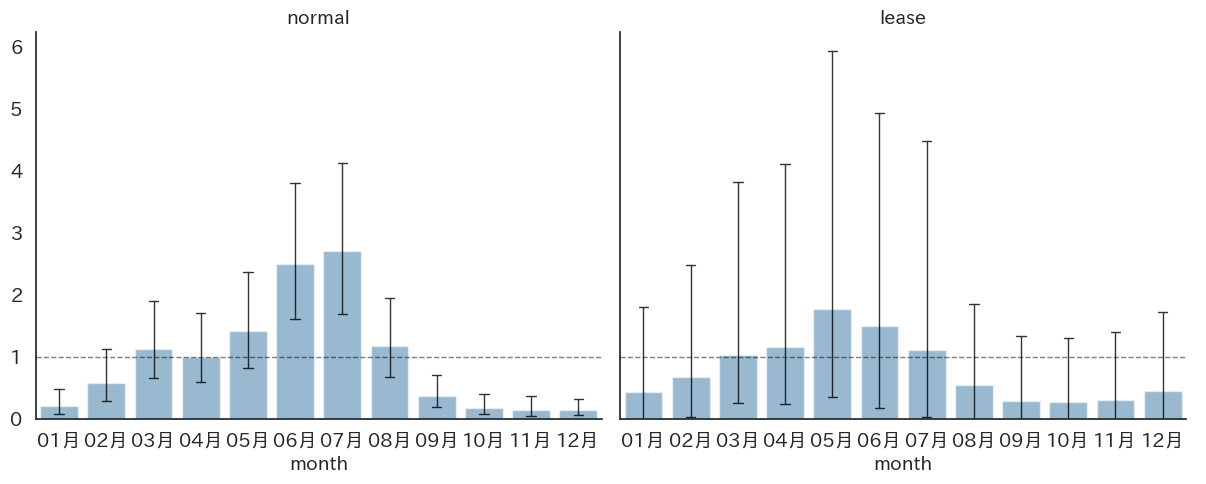

In [5]:
normal = pd.DataFrame(posterior["season_factors"][:, 0, :]).T
lease  = pd.DataFrame(posterior["season_factors"][:, 1, :]).T

months = [f"{m:02d}月" for m in range(1, 13)]
normal.index = months
lease.index  = months

# --- meltしてラベル付け ---
df_n = normal.reset_index().melt(id_vars="index", var_name="sample", value_name="factor")
df_n.columns = ["month", "sample", "factor"]
df_n["type"] = "normal"

df_l = lease.reset_index().melt(id_vars="index", var_name="sample", value_name="factor")
df_l.columns = ["month", "sample", "factor"]
df_l["type"] = "lease"

df_melted = pd.concat([df_n, df_l], ignore_index=True)
df_melted["month"] = pd.Categorical(df_melted["month"], categories=months, ordered=True)

# --- Facetで並べる（median + PI95）---
g = sns.catplot(
    data=df_melted,
    kind="bar",
    x="month",
    y="factor",
    col="type",                 # ← ここで normal / lease を並べる
    estimator="median",
    errorbar=("pi", 95),
    capsize=0.2,
    color="#1f77b4",
    alpha=0.5,
    err_kws={
        "color": "black",
        "linewidth": 1.0,
        "alpha": 0.8,
        "linestyle": "-"
    },
    height=5,
    aspect=1.2
)

# 基準線 y=1 を各パネルに
for ax in g.axes.flat:
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)

g.set_titles("{col_name}")
plt.tight_layout()

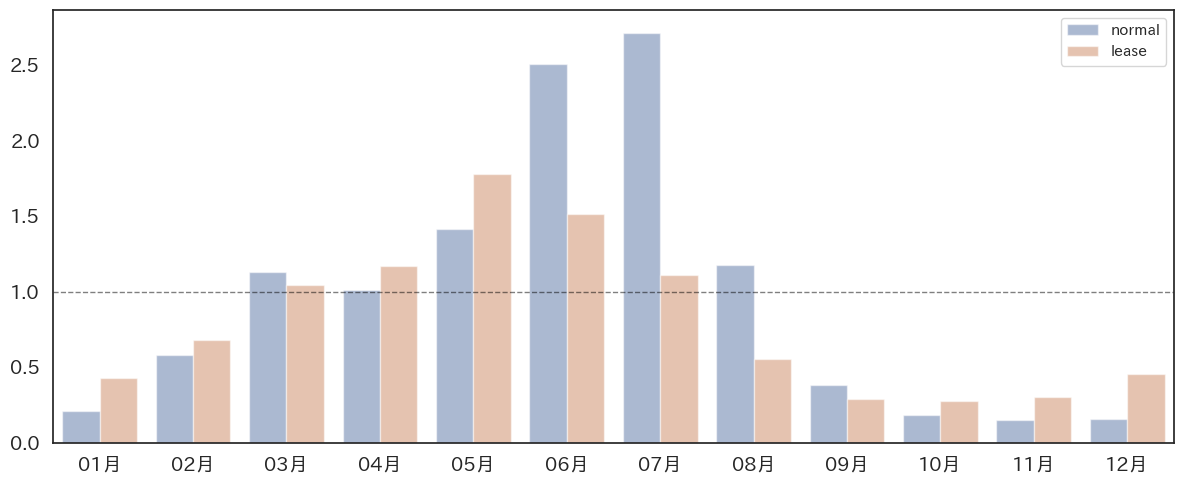

In [104]:
normal = pd.DataFrame(posterior["season_factors"][:, 0, :]).T
lease  = pd.DataFrame(posterior["season_factors"][:, 1, :]).T

months = [f"{m:02d}月" for m in range(1, 13)]
normal.index = months
lease.index  = months

df_n = normal.reset_index().melt(id_vars="index", var_name="sample", value_name="factor")
df_n.columns = ["month", "sample", "factor"]
df_n["type"] = "normal"

df_l = lease.reset_index().melt(id_vars="index", var_name="sample", value_name="factor")
df_l.columns = ["month", "sample", "factor"]
df_l["type"] = "lease"

df_melted = pd.concat([df_n, df_l], ignore_index=True)
df_melted["month"] = pd.Categorical(df_melted["month"], categories=months, ordered=True)

fig, ax = plt.subplots(1, figsize=(12, 5))

sns.barplot(
    data=df_melted,
    x="month",
    y="factor",
    hue="type",                 # ← ここで normal / lease を同一軸に
    estimator="median",
#    errorbar=("pi", 95),
#    capsize=0.2,
    alpha=0.5,
    err_kws={
        "color": "black",
        "linewidth": 0.0,
        "alpha": 0.8,
        "linestyle": "-"
    },
    ax=ax
)

ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("")
ax.set_xlabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()
plt.savefig("")

In [7]:
# sales
# pd.DataFrame(posterior['demand_pred'][:, :, 1]).median(axis=0).plot()
# pd.Series(posterior["M"][:, 1])

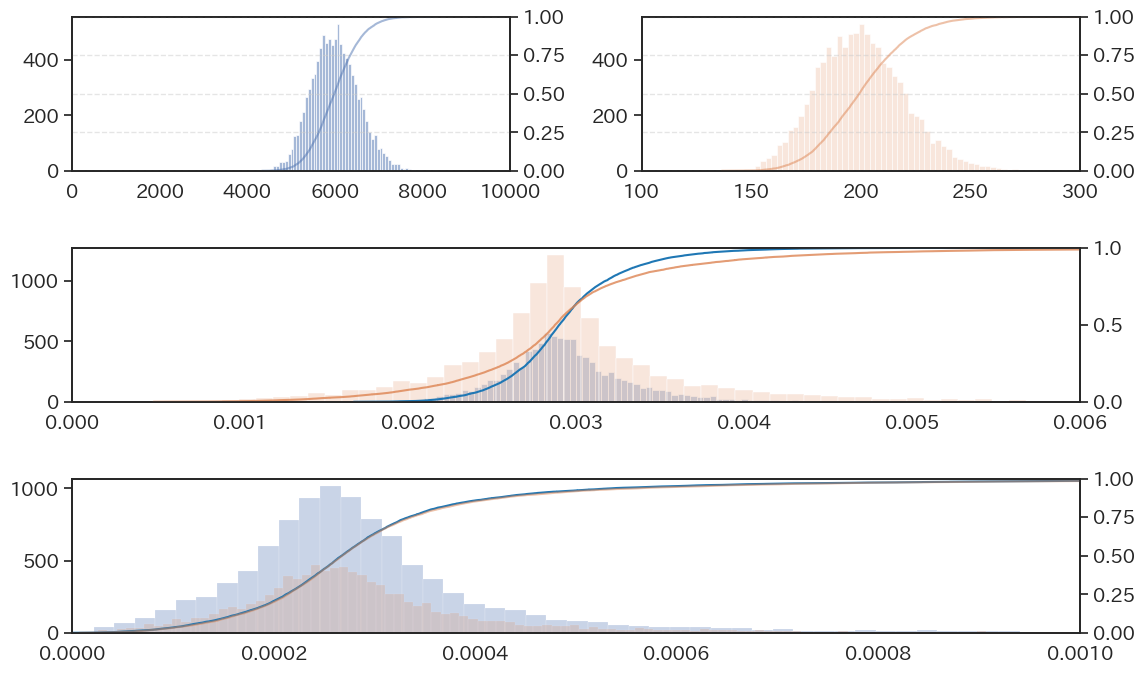

In [96]:
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.3)

# 1行目（左右2つ）
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])

# 2行目（2列結合で1つ）
ax10 = fig.add_subplot(gs[1, :])

# 3行目（左右2つ）
ax20 = fig.add_subplot(gs[2, :])

# ========= データ =========
M0 = pd.Series(posterior["M"][:, 0])
M1 = pd.Series(posterior["M"][:, 1])

# ========= 1行目：ヒスト + 累積線（右軸） =========
ax00_r = ax00.twinx()
ax01_r = ax01.twinx()

sns.histplot(M0, ax=ax00, alpha=0.5)
sns.histplot(M1, ax=ax01, alpha=0.2, color='#DD8452')

acc_M0 = M0.value_counts().sort_index().cumsum() / len(M0)
acc_M1 = M1.value_counts().sort_index().cumsum() / len(M1)

# seaborn の lineplot は data= を明示して渡すのが安全
sns.lineplot(x=acc_M0.index, y=acc_M0.values, ax=ax00_r, alpha=0.5)
sns.lineplot(x=acc_M1.index, y=acc_M1.values, ax=ax01_r, alpha=0.5, color='#DD8452')

# 右軸を揃える
for axr in (ax00_r, ax01_r):
    axr.set_ylim(0, 1.0)
    axr.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    axr.set_ylabel("")
    axr.grid(True, which="major", linestyle="--", alpha=0.5)

# 左軸（ヒスト側）の設定
ax00.set_xlim(0, 10000)
ax00.set_ylabel("")

ax01.set_xlim(100, 300)
ax01.set_ylabel("")

# ======

ax10_ = ax10.twinx()
p0 = pd.Series(np.exp(posterior["log_p"][:, 0]))
p1 = pd.Series(np.exp(posterior["log_p"][:, 1]))

acc_p0 = p0.value_counts().sort_index().cumsum() / len(p0)
acc_p1 = p1.value_counts().sort_index().cumsum() / len(p1)

sns.histplot(p0, ax=ax10, alpha=0.3)
sns.histplot(p1, ax=ax10, alpha=0.2, color='#DD8452')
ax10.set_ylabel("")

sns.lineplot(x=acc_p0.index, y=acc_p0.values, color='#1f77b4', ax=ax10_)
sns.lineplot(x=acc_p1.index, y=acc_p1.values, color='#DD8452', ax=ax10_, alpha=0.8)
ax10_.set_ylim((0, 1))
ax10_.set_xlim((0, 0.006))


ax20_ = ax20.twinx()
q0 = pd.Series(np.exp(posterior["log_q"][:, 0]))
q1 = pd.Series(np.exp(posterior["log_q"][:, 1]))

acc_q0 = q0.value_counts().sort_index().cumsum() / len(q0)
acc_q1 = q1.value_counts().sort_index().cumsum() / len(q1)

sns.histplot(q0, ax=ax20, alpha=0.3, bins=500)
sns.histplot(q1, ax=ax20, alpha=0.2, bins=500, color='#DD8452')
ax20.set_ylabel("")

sns.lineplot(x=acc_q0.index, y=acc_q0.values, color='#1f77b4', ax=ax20_)
sns.lineplot(x=acc_q1.index, y=acc_q1.values, color='#DD8452', ax=ax20_, alpha=0.5)
ax20_.set_ylim((0, 1))
ax20_.set_xlim((0, 0.001))
ax20_.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

plt.savefig("images/M_p_q02.pdf", format='pdf', transparent=True)

In [88]:
posterior

{'M': Array([[5959.4062 ,  199.88026],
        [6774.9785 ,  189.32307],
        [5744.2046 ,  205.03636],
        ...,
        [6262.808  ,  178.83556],
        [5250.042  ,  191.08539],
        [6460.083  ,  198.44464]], dtype=float32),
 'M_01': Array([449.9741 , 459.19626, 295.35873, ..., 211.32938, 451.33966,
        309.71414], dtype=float32),
 'M_10': Array([14.730185,  3.74069 , 16.698788, ..., 19.618095, 11.22769 ,
        12.399191], dtype=float32),
 'alpha': Array([[2.274235  , 0.3253562 ],
        [1.4462967 , 0.21743003],
        [1.4157677 , 0.21128374],
        ...,
        [1.4922438 , 0.31618547],
        [1.4410497 , 0.38999867],
        [1.6169369 , 0.3246055 ]], dtype=float32),
 'boost_strength': Array([0.01266381, 0.013873  , 0.01436143, ..., 0.0124205 , 0.01521754,
        0.01377721], dtype=float32),
 'demand_pred': Array([[[19.67108   ,  0.5374431 ],
         [14.222646  ,  0.9059319 ],
         [21.439896  ,  1.0658072 ],
         ...,
         [12.394108  ,  0.

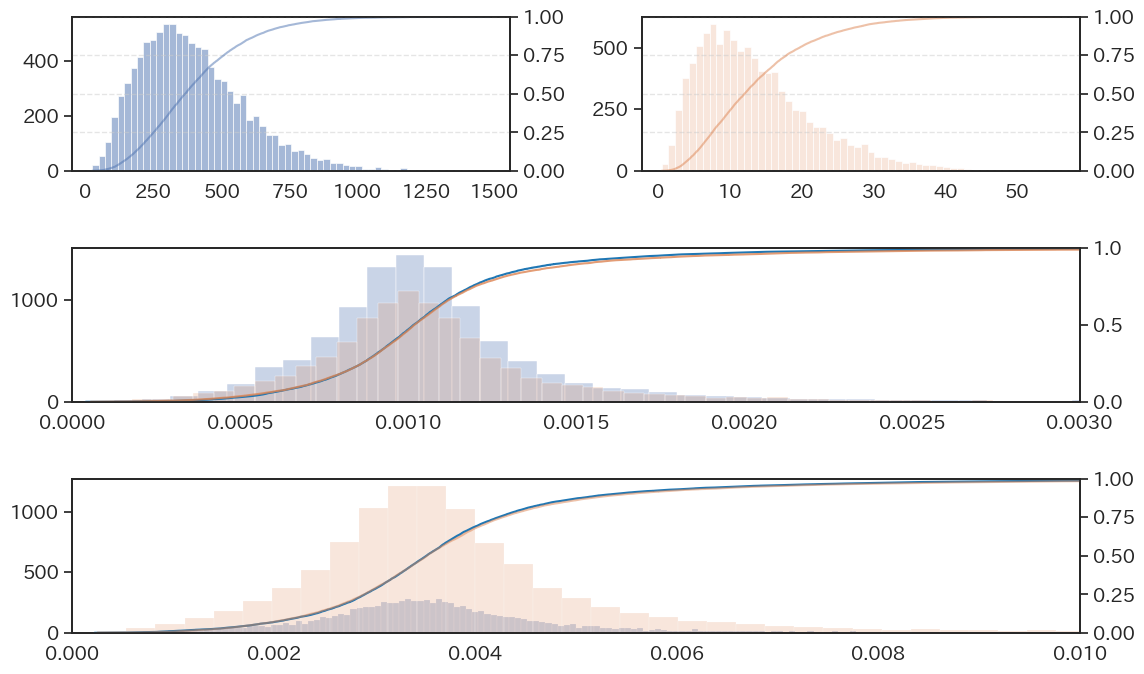

In [97]:
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.3)

# 1行目（左右2つ）
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])

# 2行目（2列結合で1つ）
ax10 = fig.add_subplot(gs[1, :])

# 3行目（左右2つ）
ax20 = fig.add_subplot(gs[2, :])

# ========= データ =========
M0 = pd.Series(posterior["M_01"][:])
M1 = pd.Series(posterior["M_10"][:])

# ========= 1行目：ヒスト + 累積線（右軸） =========
ax00_r = ax00.twinx()
ax01_r = ax01.twinx()

sns.histplot(M0, ax=ax00, alpha=0.5)
sns.histplot(M1, ax=ax01, alpha=0.2, color='#DD8452')

acc_M0 = M0.value_counts().sort_index().cumsum() / len(M0)
acc_M1 = M1.value_counts().sort_index().cumsum() / len(M1)

# seaborn の lineplot は data= を明示して渡すのが安全
sns.lineplot(x=acc_M0.index, y=acc_M0.values, ax=ax00_r, alpha=0.5)
sns.lineplot(x=acc_M1.index, y=acc_M1.values, ax=ax01_r, alpha=0.5, color='#DD8452')

# 右軸を揃える
for axr in (ax00_r, ax01_r):
    axr.set_ylim(0, 1.0)
    axr.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    axr.set_ylabel("")
    axr.grid(True, which="major", linestyle="--", alpha=0.5)

# 左軸（ヒスト側）の設定
# ax00.set_xlim(0, 10000)
ax00.set_ylabel("")

# ax01.set_xlim(100, 300)
ax01.set_ylabel("")

# ======

ax10_ = ax10.twinx()
p0 = pd.Series(np.exp(posterior["log_p_01"][:]))
p1 = pd.Series(np.exp(posterior["log_p_10"][:]))

acc_p0 = p0.value_counts().sort_index().cumsum() / len(p0)
acc_p1 = p1.value_counts().sort_index().cumsum() / len(p1)

sns.histplot(p0, ax=ax10, alpha=0.3)
sns.histplot(p1, ax=ax10, alpha=0.2, color='#DD8452')
ax10.set_ylabel("")

sns.lineplot(x=acc_p0.index, y=acc_p0.values, color='#1f77b4', ax=ax10_)
sns.lineplot(x=acc_p1.index, y=acc_p1.values, color='#DD8452', ax=ax10_, alpha=0.8)
ax10_.set_ylim((0, 1))
ax10_.set_xlim((0, 0.003))


ax20_ = ax20.twinx()
q0 = pd.Series(np.exp(posterior["log_q_01"][:]))
q1 = pd.Series(np.exp(posterior["log_q_10"][:]))

acc_q0 = q0.value_counts().sort_index().cumsum() / len(q0)
acc_q1 = q1.value_counts().sort_index().cumsum() / len(q1)

sns.histplot(q0, ax=ax20, alpha=0.3, bins=500)
sns.histplot(q1, ax=ax20, alpha=0.2, bins=500, color='#DD8452')
ax20.set_ylabel("")

sns.lineplot(x=acc_q0.index, y=acc_q0.values, color='#1f77b4', ax=ax20_)
sns.lineplot(x=acc_q1.index, y=acc_q1.values, color='#DD8452', ax=ax20_, alpha=0.5)
ax20_.set_ylim((0, 1))
ax20_.set_xlim((0, 0.01))
ax20_.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

plt.savefig("images/migration_M_p_q.pdf", format='pdf', transparent=True)